In [2]:
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.metrics import (
    roc_auc_score, recall_score, precision_score, 
    f1_score, accuracy_score, confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

# Set random seed for reproducibility
np.random.seed(42)

In [3]:
# Load the result
tfidf_df = pd.read_csv('tfidf_baseline_pred.csv')
vanilla_df = pd.read_csv('1_no_kg_pred.csv')
kg_df = pd.read_csv('3_kg_tfidf_pred.csv')
agent_df = pd.read_csv('multi_agent.csv')

In [4]:
# Uniform variable
y_true_tfidf = tfidf_df['true_label'].values
y_pred_tfidf = tfidf_df['pred_label'].values
y_prob_tfidf = tfidf_df['prob_CATH'].values

y_true_vanilla = vanilla_df['true_label'].values
y_pred_vanilla = vanilla_df['pred_label'].values
y_prob_vanilla = vanilla_df['prob_CATH'].values

y_true_kg = kg_df['true_label'].values
y_pred_kg = kg_df['pred_label'].values
y_prob_kg = kg_df['prob_CATH'].values

y_true_agent = agent_df['true_cath'].values
y_pred_agent = agent_df['pred_cath'].values
y_prob_agent = agent_df['cath_probability'].values

In [ ]:
# Validate all use same test set
assert len(y_true_tfidf) == len(y_true_vanilla) == len(y_true_kg) == len(y_true_agent)
assert np.all(y_true_tfidf == y_true_vanilla)
assert np.all(y_true_tfidf == y_true_kg)
assert np.all(y_true_tfidf == y_true_agent)

y_true = y_true_tfidf  # Ground truth labels to check
n_samples = len(y_true)

print(f"Positive class (CATH): {y_true.sum()} ({y_true.mean()*100:.1f}%)")
print(f"Negative class: {(1-y_true).sum()} ({(1-y_true).mean()*100:.1f}%)")

Positive class (CATH): 145 (30.4%)
Negative class: 332 (69.6%)


## Bootstrap Confidence Interval

In [6]:
def bootstrap_metric(y_true, y_pred, y_prob, metric_func, n_bootstrap=2000, ci=0.95):
    """    
    Args:
        y_true: Ground truth labels
        y_pred: Predicted labels (for classification metrics)
        y_prob: Predicted probabilities (for AUC)
        metric_func: Function that takes (y_true, y_pred, y_prob) and returns a scalar
        n_bootstrap: Number of bootstrap samples
        ci: Confidence interval (default 95%)
    
    Returns:
        (point_estimate, lower_bound, upper_bound)
    """
    point_estimate = metric_func(y_true, y_pred, y_prob)
    
    bootstrap_estimates = []
    
    for _ in range(n_bootstrap):
        # Resample with replacement
        indices = np.random.choice(len(y_true), size=len(y_true), replace=True)
        y_true_boot = y_true[indices]
        y_pred_boot = y_pred[indices]
        y_prob_boot = y_prob[indices]
        
        # Handle edge cases where bootstrap sample has only one class
        if len(np.unique(y_true_boot)) < 2:
            continue
            
        try:
            estimate = metric_func(y_true_boot, y_pred_boot, y_prob_boot)
            bootstrap_estimates.append(estimate)
        except:
            continue
    
    bootstrap_estimates = np.array(bootstrap_estimates)
    
    # Calculate confidence interval
    alpha = 1 - ci
    lower = np.percentile(bootstrap_estimates, 100 * alpha / 2)
    upper = np.percentile(bootstrap_estimates, 100 * (1 - alpha / 2))
    
    return point_estimate, lower, upper


In [7]:
# Define metric functions
def auc_func(y_true, y_pred, y_prob):
    return roc_auc_score(y_true, y_prob)

def recall_func(y_true, y_pred, y_prob):
    return recall_score(y_true, y_pred, pos_label=1, zero_division=0)

def precision_func(y_true, y_pred, y_prob):
    return precision_score(y_true, y_pred, pos_label=1, zero_division=0)

def f1_func(y_true, y_pred, y_prob):
    return f1_score(y_true, y_pred, pos_label=1, zero_division=0)

def accuracy_func(y_true, y_pred, y_prob):
    return accuracy_score(y_true, y_pred)

In [15]:
# Execution
models = {
    'TF-IDF': (y_pred_tfidf, y_prob_tfidf),
    'Vanilla ClinicalBERT': (y_pred_vanilla, y_prob_vanilla),
    'ClinicalBERT with KG': (y_pred_kg, y_prob_kg),
    'Multi-Agent': (y_pred_agent, y_prob_agent)
}

results_table = []

for model_name, (y_pred, y_prob) in models.items():
    print(f"\n{model_name}:")
    
    # Calculate metrics with CIs
    auc_est, auc_low, auc_high = bootstrap_metric(y_true, y_pred, y_prob, auc_func)
    recall_est, recall_low, recall_high = bootstrap_metric(y_true, y_pred, y_prob, recall_func)
    prec_est, prec_low, prec_high = bootstrap_metric(y_true, y_pred, y_prob, precision_func)
    f1_est, f1_low, f1_high = bootstrap_metric(y_true, y_pred, y_prob, f1_func)
    acc_est, acc_low, acc_high = bootstrap_metric(y_true, y_pred, y_prob, accuracy_func)
    
    print(f"ROC-AUC:   {auc_est:.3f} [{auc_low:.3f}, {auc_high:.3f}]")
    print(f"Recall:    {recall_est:.3f} [{recall_low:.3f}, {recall_high:.3f}]")
    print(f"Precision: {prec_est:.3f} [{prec_low:.3f}, {prec_high:.3f}]")
    print(f"F1-Score:  {f1_est:.3f} [{f1_low:.3f}, {f1_high:.3f}]")
    print(f"Accuracy:  {acc_est:.3f} [{acc_low:.3f}, {acc_high:.3f}]")
    
    results_table.append({
        'Model': model_name,
        'AUC': f"{auc_est:.3f} [{auc_low:.3f}-{auc_high:.3f}]",
        'Recall': f"{recall_est:.3f} [{recall_low:.3f}-{recall_high:.3f}]",
        'Precision': f"{prec_est:.3f} [{prec_low:.3f}-{prec_high:.3f}]",
        'F1': f"{f1_est:.3f} [{f1_low:.3f}-{f1_high:.3f}]"
    })

# Save results table
results_df = pd.DataFrame(results_table)
results_df.to_csv('bootstrap_results.csv', index=False)



TF-IDF:
ROC-AUC:   0.806 [0.764, 0.848]
Recall:    0.669 [0.592, 0.745]
Precision: 0.588 [0.512, 0.665]
F1-Score:  0.626 [0.562, 0.683]
Accuracy:  0.757 [0.719, 0.792]

Vanilla ClinicalBERT:
ROC-AUC:   0.581 [0.528, 0.636]
Recall:    0.000 [0.000, 0.000]
Precision: 0.000 [0.000, 0.000]
F1-Score:  0.000 [0.000, 0.000]
Accuracy:  0.696 [0.654, 0.740]

ClinicalBERT with KG:
ROC-AUC:   0.751 [0.699, 0.797]
Recall:    0.566 [0.483, 0.642]
Precision: 0.621 [0.533, 0.705]
F1-Score:  0.592 [0.518, 0.655]
Accuracy:  0.763 [0.723, 0.801]

Multi-Agent:
ROC-AUC:   0.730 [0.675, 0.779]
Recall:    0.883 [0.830, 0.933]
Precision: 0.340 [0.293, 0.389]
F1-Score:  0.491 [0.435, 0.544]
Accuracy:  0.444 [0.403, 0.488]


## McNemar's Test for Paired Comparisons

In [16]:
def mcnemar_test(y_true, y_pred_1, y_pred_2):
    """
    Perform McNemar's test to compare two classifiers
    
    Returns:
        statistic, p_value, contingency_table
    """
    # Create contingency table
    # n01: model 1 wrong, model 2 correct
    # n10: model 1 correct, model 2 wrong
    correct_1 = (y_pred_1 == y_true)
    correct_2 = (y_pred_2 == y_true)
    
    n01 = np.sum(~correct_1 & correct_2)
    n10 = np.sum(correct_1 & ~correct_2)
    
    # Create full contingency table
    n00 = np.sum(~correct_1 & ~correct_2)
    n11 = np.sum(correct_1 & correct_2)
    
    contingency = np.array([[n11, n10], [n01, n00]])
    
    # McNemar's test with continuity correction
    if (n01 + n10) > 0:
        statistic = (abs(n01 - n10) - 1)**2 / (n01 + n10)
        p_value = 1 - stats.chi2.cdf(statistic, df=1)
    else:
        statistic = 0
        p_value = 1.0
    
    return statistic, p_value, contingency

In [17]:
# Execution

print("H0: The two classifiers have the same error rate")
print("H1: The two classifiers have different error rates")
print("Reject H0 if p < 0.05 (statistically significant difference)")

model_predictions = {
    'TF-IDF': y_pred_tfidf,
    'Vanilla BERT': y_pred_vanilla,
    'Enhanced KG': y_pred_kg,
    'Multi-Agent': y_pred_agent
}

mcnemar_results = []

# Compare all pairs
model_names = list(model_predictions.keys())
for i, model1 in enumerate(model_names):
    for model2 in model_names[i+1:]:
        y_pred1 = model_predictions[model1]
        y_pred2 = model_predictions[model2]
        
        stat, p_val, contingency = mcnemar_test(y_true, y_pred1, y_pred2)
        
        # Determine which model is better
        acc1 = accuracy_score(y_true, y_pred1)
        acc2 = accuracy_score(y_true, y_pred2)
        
        better = model1 if acc1 > acc2 else model2
        sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
        
        print(f"\n{model1} vs {model2}:")
        print(f"  Chi-square statistic: {stat:.3f}")
        print(f"  p-value: {p_val:.4f} {sig}")
        print(f"  Better model: {better} (acc: {acc1:.3f} vs {acc2:.3f})")
        print(f"  Contingency table:")
        print(f"    Both correct: {contingency[0,0]}, {model1} only: {contingency[0,1]}")
        print(f"    {model2} only: {contingency[1,0]}, Both wrong: {contingency[1,1]}")
        
        mcnemar_results.append({
            'Comparison': f"{model1} vs {model2}",
            'Chi-square': f"{stat:.3f}",
            'p-value': f"{p_val:.4f}",
            'Significance': sig,
            'Better Model': better
        })

mcnemar_df = pd.DataFrame(mcnemar_results)
mcnemar_df.to_csv('mcnemar_tests.csv', index=False)

H0: The two classifiers have the same error rate
H1: The two classifiers have different error rates
Reject H0 if p < 0.05 (statistically significant difference)

TF-IDF vs Vanilla BERT:
  Chi-square statistic: 4.752
  p-value: 0.0293 *
  Better model: TF-IDF (acc: 0.757 vs 0.696)
  Contingency table:
    Both correct: 264, TF-IDF only: 97
    Vanilla BERT only: 68, Both wrong: 48

TF-IDF vs Enhanced KG:
  Chi-square statistic: 0.052
  p-value: 0.8197 ns
  Better model: Enhanced KG (acc: 0.757 vs 0.763)
  Contingency table:
    Both correct: 324, TF-IDF only: 37
    Enhanced KG only: 40, Both wrong: 76

TF-IDF vs Multi-Agent:
  Chi-square statistic: 94.009
  p-value: 0.0000 ***
  Better model: TF-IDF (acc: 0.757 vs 0.444)
  Contingency table:
    Both correct: 170, TF-IDF only: 191
    Multi-Agent only: 42, Both wrong: 74

Vanilla BERT vs Enhanced KG:
  Chi-square statistic: 7.280
  p-value: 0.0070 **
  Better model: Enhanced KG (acc: 0.696 vs 0.763)
  Contingency table:
    Both correc

In [20]:
sig_comparisons = mcnemar_df[mcnemar_df['Significance'] != 'ns']
if len(sig_comparisons) > 0:
    print(f"   - {len(sig_comparisons)} statistically significant differences found")
    for _, row in sig_comparisons.iterrows():
        print(f"   - {row['Comparison']}: p={row['p-value']} ({row['Significance']})")
else:
    print("   - No statistically significant differences at α=0.05")

   - 5 statistically significant differences found
   - TF-IDF vs Vanilla BERT: p=0.0293 (*)
   - TF-IDF vs Multi-Agent: p=0.0000 (***)
   - Vanilla BERT vs Enhanced KG: p=0.0070 (**)
   - Vanilla BERT vs Multi-Agent: p=0.0000 (***)
   - Enhanced KG vs Multi-Agent: p=0.0000 (***)


## Visualization

In [18]:
# Extract data for plotting
model_names_plot = []
recalls = []
recall_lows = []
recall_highs = []
aucs = []
auc_lows = []
auc_highs = []

for model_name, (y_pred, y_prob) in models.items():
    model_names_plot.append(model_name)
    
    recall_est, recall_low, recall_high = bootstrap_metric(y_true, y_pred, y_prob, recall_func)
    recalls.append(recall_est)
    recall_lows.append(recall_low)
    recall_highs.append(recall_high)
    
    auc_est, auc_low, auc_high = bootstrap_metric(y_true, y_pred, y_prob, auc_func)
    aucs.append(auc_est)
    auc_lows.append(auc_low)
    auc_highs.append(auc_high)

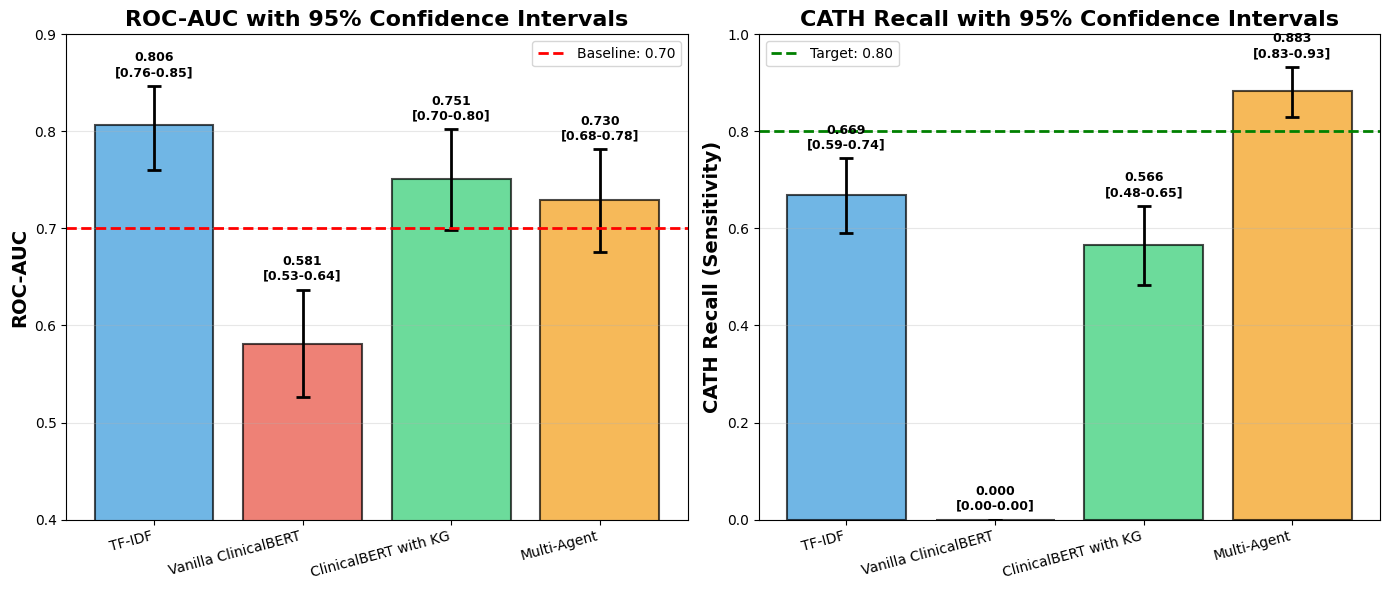

In [19]:
# Create figure
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: ROC-AUC with error bars
x_pos = np.arange(len(model_names_plot))
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

axes[0].bar(x_pos, aucs, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
axes[0].errorbar(x_pos, aucs, 
                 yerr=[np.array(aucs) - np.array(auc_lows), 
                       np.array(auc_highs) - np.array(aucs)],
                 fmt='none', color='black', capsize=5, capthick=2, linewidth=2)
axes[0].set_ylabel('ROC-AUC', fontsize=14, fontweight='bold')
axes[0].set_title('ROC-AUC with 95% Confidence Intervals', fontsize=16, fontweight='bold')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(model_names_plot, rotation=15, ha='right')
axes[0].set_ylim(0.4, 0.9)
axes[0].axhline(y=0.7, color='red', linestyle='--', linewidth=2, label='Baseline: 0.70')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Add value labels on top of bars
for i, (v, l, h) in enumerate(zip(aucs, auc_lows, auc_highs)):
    axes[0].text(i, h + 0.01, f"{v:.3f}\n[{l:.2f}-{h:.2f}]", 
                ha='center', fontsize=9, fontweight='bold')

# Plot 2: CATH Recall with error bars
axes[1].bar(x_pos, recalls, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
axes[1].errorbar(x_pos, recalls,
                 yerr=[np.array(recalls) - np.array(recall_lows),
                       np.array(recall_highs) - np.array(recalls)],
                 fmt='none', color='black', capsize=5, capthick=2, linewidth=2)
axes[1].set_ylabel('CATH Recall (Sensitivity)', fontsize=14, fontweight='bold')
axes[1].set_title('CATH Recall with 95% Confidence Intervals', fontsize=16, fontweight='bold')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(model_names_plot, rotation=15, ha='right')
axes[1].set_ylim(0, 1.0)
axes[1].axhline(y=0.8, color='green', linestyle='--', linewidth=2, label='Target: 0.80')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

# Add value labels
for i, (v, l, h) in enumerate(zip(recalls, recall_lows, recall_highs)):
    axes[1].text(i, h + 0.02, f"{v:.3f}\n[{l:.2f}-{h:.2f}]",
                ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('statistical_comparison.png', dpi=300, bbox_inches='tight')
